# Problem Formulation

The dataset is an ongoing cardiovascular study consisting of 4,240 middle-aged adults (ages 32–70) from Framingham, Massachusetts. It observes a 10-year follow-up period and analyzes whether patients develop or do not develop coronary heart disease within 10 years based on 15 features, including demographic features and health attributes.

Data can be found here: https://www.kaggle.com/datasets/noeyislearning/framingham-heart-study

**Inferential Question**: What is the mean total cholesterol among adults who develop Coronary Heart Disease within 10 years?

In this scenario, the parameter of interest is the true population mean total cholesterol levels among adults who develop coronary heart disease within 10 years, which will be estimated using the sample cholesterol mean from this dataset where TenYearCHD is 1.

**Predictive Task (Regression)**: Can we accurately predict whether an individual will develop coronary heart disease (target variable) within 10 years using all features? List of features:
- Sex 
- Age
- Education
- Smoking status
- Number of cigarettes smoked per day
- Whether a patient is on blood pressure medication or not    
- Whether a patient has had a stroke before or not
- Whether a patient has a history of hypertension or not
- Diabetes status
- Total cholesterol levels
- Systolic blood pressure levels
- Diastolic blood pressure levels
- Body Mass Index
- Heart rate
- Glucose levels

These tasks differ, as the goal of the inferential task will be to quantify uncertainty regarding total cholesterol levels (the population parameter), whereas the goal of the predictive task will be to maximize out-of-sample predictive performance for a future, unseen observation using F-1 score and PR-AUC as the evaluation metrics and binary cross-entropy as the loss function.


# Data Preprocessing

In [1]:
# Importing libraries
import pandas as pd

# Loading the dataset
df = pd.read_csv('data/framingham_heart_study.csv')

df.head()



,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [2]:
# Checking for missing values

print(df.isnull().sum())
print(df.shape)


male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64
(4240, 16)


In [3]:
# Dropping rows with missing values
df.dropna(inplace=True)
print(df.shape)


(3658, 16)


The new sample size is 3658 patients

In [4]:
# Ensuring numeric data types
print(df.dtypes)

male                 int64
age                  int64
education          float64
currentSmoker        int64
cigsPerDay         float64
BPMeds             float64
prevalentStroke      int64
prevalentHyp         int64
diabetes             int64
totChol            float64
sysBP              float64
diaBP              float64
BMI                float64
heartRate          float64
glucose            float64
TenYearCHD           int64
dtype: object


# EDA

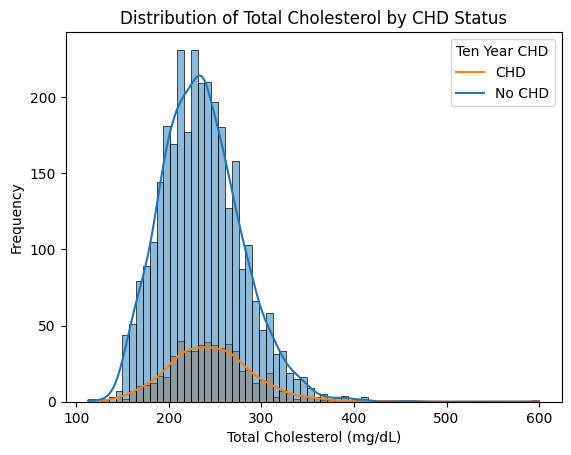

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of total cholesterol for CHD vs non-CHD

sns.histplot(data=df, x='totChol', hue='TenYearCHD', kde=True)
plt.title('Distribution of Total Cholesterol by CHD Status')
plt.xlabel('Total Cholesterol (mg/dL)')
plt.ylabel('Frequency')
plt.legend(title='Ten Year CHD', labels=['CHD', 'No CHD'])
plt.show()

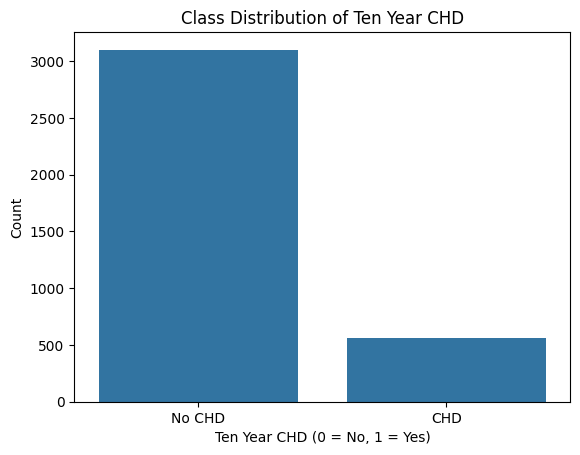

In [6]:
# Plotting class imbalance in the target variable 'TenYearCHD'

sns.countplot(x='TenYearCHD', data=df)
plt.title('Class Distribution of Ten Year CHD')
plt.xlabel('Ten Year CHD (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.xticks([0, 1], ['No CHD', 'CHD'])
plt.show()

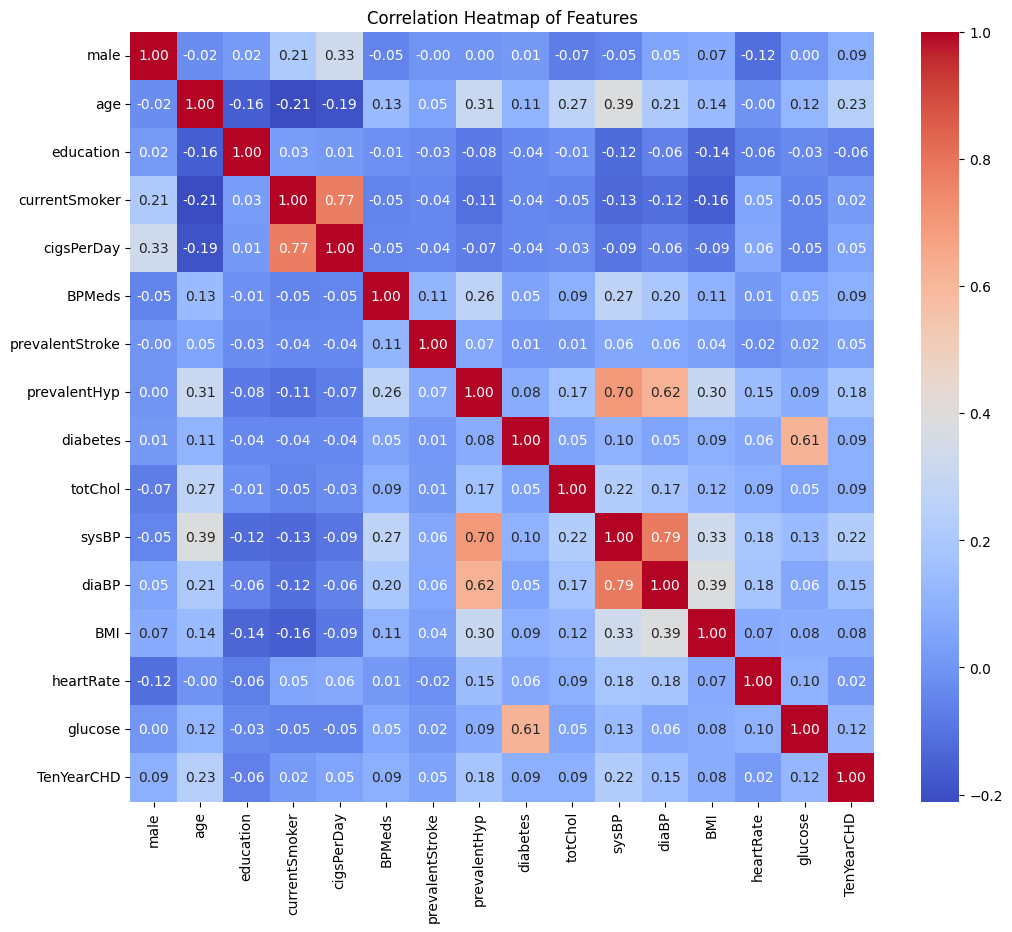

In [7]:
# Correlation heatmap of features
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap of Features')
plt.show()

# Likelihood and Estimation

In [8]:
# Extracting total cholesterol values for patients with CHD
chol_chd = df[df['TenYearCHD'] == 1]['totChol']
n = len(chol_chd)
print(f"Number of CHD patients: {n}")

Number of CHD patients: 557


### Likelihood Formulation

We model total cholesterol for CHD patients as i.i.d. Normal ($x_i \sim \mathcal{N}(\mu, \sigma^2)$):

$$L(\mu, \sigma^2 \mid x_1, \ldots, x_n) = \prod_{i=1}^{n} \frac{1}{\sqrt{2\pi\sigma^2}} \exp\!\left(-\frac{(x_i - \mu)^2}{2\sigma^2}\right)$$

Maximizing over $\mu$ gives the MLE for the total mean cholesterol level $\hat{\mu} = \bar{x}$, and over $\sigma^2$ gives $\hat{\sigma}^2 = \frac{1}{n}\sum_{i=1}^{n}(x_i - \bar{x})^2$ with 0 delta degrees of freedom (ddof = 0).

### MLE Computation

In [9]:
# Calculating mean and standard deviation of total cholesterol for CHD patients
mu_mle, sigma = chol_chd.mean(), chol_chd.std(ddof = 0)

print(f"MLE for mean cholesterol: {mu_mle:.4f}")

MLE for mean cholesterol: 246.3501


### Likelihood Visualization

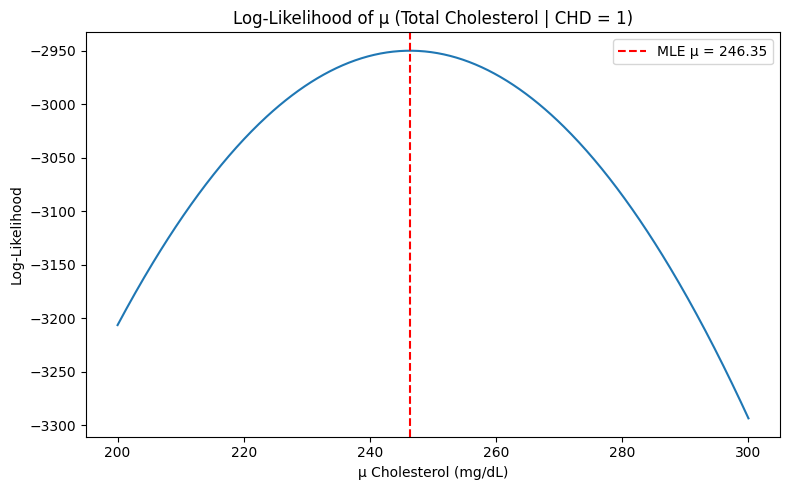

In [10]:
from scipy.stats import norm
import numpy as np

# Range of mu values to evaluate likelihood
mu_range = np.linspace(200, 300, 500)

# Computing log-likelihood for each mu value
log_likelihood = [
    np.sum(norm.logpdf(chol_chd, loc=mu, scale=sigma))
    for mu in mu_range
]

# Plotting log-likelihood as a function of mu
plt.figure(figsize=(8, 5))
plt.plot(mu_range, log_likelihood)
plt.axvline(mu_mle, color='red', linestyle='--', label=f'MLE μ = {mu_mle:.2f}')
plt.title('Log-Likelihood of μ (Total Cholesterol | CHD = 1)')
plt.xlabel('μ Cholesterol (mg/dL)')
plt.ylabel('Log-Likelihood')
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation of Estimator Properties

Given that the distribution of cholesterol values is approximately normal for patients that develop coronary heart disease, the MLE for the mean cholesterol level is the sample mean (246.35 mg/dL), represented by the peak of the above plot. It is an unbiased and a consistent estimator, as increasing sample size will result in the convergence of the sample mean to the true population mean. The MLE for the mean cholesterol level among CHD patients is also the most efficient estimator, as the sample mean has the lowest variance for a normal distribution.

# Frequentist Inference

### Sampling Distribution Reasoning

From the Central Limit Theorem, the sampling distribution of our sample mean is approximately normal, as we have 557 data points which is sufficiently large. The standard error of the mean will represent the variability of the sample mean across repeated samples.

### Theory-based Confidence Interval

In [11]:
from scipy import stats

# Theory-based 95% confidence interval
se = chol_chd.std(ddof=1) / np.sqrt(n)

# Calculating the confidence interval using the t-distribution
ci_lower, ci_upper = stats.t.interval(0.95, df=n-1, loc=mu_mle, scale=se)

print(f"Standard error: {se:.4f} mg/dL")
print(f"95% CI: ({ci_lower:.4f}, {ci_upper:.4f})")

Standard error: 2.0481 mg/dL
95% CI: (242.3272, 250.3730)


### Bootstrap Confidence Interval

In [12]:
# 95% confidence interval using bootstrap

np.random.seed(42)
n_bootstraps = 10000
bootstrap_means = []

# Generating bootstrap samples and calculating mean for each sample
for _ in range(n_bootstraps):
    sample = chol_chd.sample(n=n, replace=True)
    bootstrap_means.append(sample.mean())

bootstrap_means = np.array(bootstrap_means)

# Calculating 95% confidence interval from bootstrap distribution
ci_lower_boot = np.percentile(bootstrap_means, 2.5)
ci_upper_boot = np.percentile(bootstrap_means, 97.5)

print(f"Bootstrap 95% CI: ({ci_lower_boot:.4f}, {ci_upper_boot:.4f})")

Bootstrap 95% CI: (242.4881, 250.4328)


### Hypothesis Testing

We use a hypothesis test (two-sample t-test) to compare the mean cholesterol levels between patients who did not develop coronary heart disease and patients who did develop coronary heart disease within 10 years.

- **Null Hypothesis (H₀):** $\mu_{CHD} = \mu_{no CHD}$
- **Alternative Hypothesis (H₁):** $\mu_{CHD} > \mu_{no CHD}$

In [13]:
# Filtering total cholesterol values for patients without CHD
chol_no_chd = df[df['TenYearCHD'] == 0]['totChol']

# Two-sample t-test for CHD vs non-CHD cholesterol 
t_stat, p_value = stats.ttest_ind(chol_chd, chol_no_chd, alternative='greater')

print(f"CHD mean: {chol_chd.mean():.4f} mg/dL")
print(f"No CHD mean: {chol_no_chd.mean():.4f} mg/dL")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

CHD mean: 246.3501 mg/dL
No CHD mean: 235.1409 mg/dL
T-statistic: 5.5459
P-value: 0.0000


### Interpretation of results

The confidence level of 95% used in both the theory-based and bootstrap confidence intervals indicates that, if we repeated this sampling procedure many times, 95% of intervals would contain the true population mean cholesterol among adults who develop coronary heart disease within 10 years. The theory-based 95% confidence interval of (242.33, 250.37) mg/dL and the bootstrap 95% confidence interval of (242.4881, 250.4328) mg/dL reflect extremely similar ranges of values for the population mean cholesterol level, quantifying our uncertainty around μ.

The p-value of ~0 is less than 0.05, meaning that we reject the null hypothesis, as evidence supports the mean cholesterol levels for patients who develop coronary heart disease within 10 years to be greater than mean cholesterol levels for those who do not. The T-statistic of ~ 5.55 indicates that the observed data would be very unlikely to occur if the null hypothesis were true, suggesting statistical significance in the alternative hypothesis. 

# Bayesian Estimation

### Prior Specification and Justification

We use a **Normal-Normal conjugate model**, treating σ² is treated as known and fixed at the MLE estimate (σ̂ ≈ 48.3 mg/dL), a standard simplification that enables the Normal-Normal conjugate model and is reasonable given the large sample size (n = 557). Under this model:

$$\mu \sim \mathcal{N}(\mu_0, \tau_0^2) \qquad x_i \mid \mu \sim \mathcal{N}(\mu, \sigma^2)$$

**Prior choice:** μ₀ = 200 mg/dL, τ₀ = 30 mg/dL.
- The CDC classifies cholesterol below 200 mg/dL as "desirable" — a sensible population baseline *before* conditioning on CHD status.
- τ₀ = 30 is weakly informative (±60 mg/dL plausible range).

### Posterior Computation

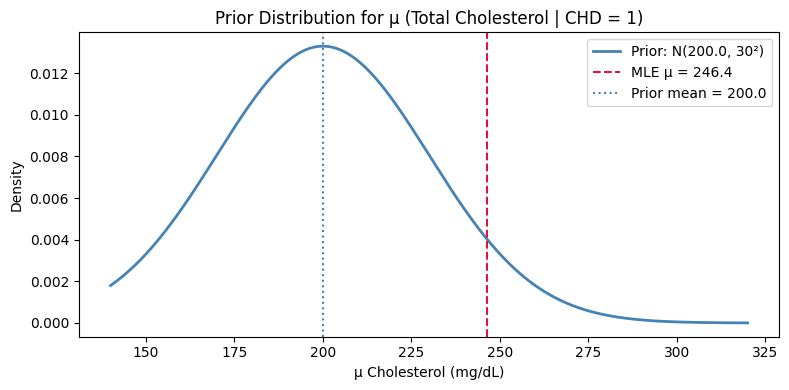

Prior mean: 200.0 mg/dL | Prior std: 30.0 mg/dL | MLE: 246.35 mg/dL (gap = 46.4)


In [14]:
sigma = chol_chd.std(ddof=0)  # known sigma (MLE estimate)
mu_0, tau_0 = 200.0, 30.0

mu_range = np.linspace(140, 320, 1000)
plt.figure(figsize=(8, 4))
plt.plot(mu_range, norm.pdf(mu_range, mu_0, tau_0), color='steelblue', lw=2, label=f'Prior: N({mu_0}, {int(tau_0)}²)')
plt.axvline(mu_mle, color='crimson',   linestyle='--', label=f'MLE μ = {mu_mle:.1f}')
plt.axvline(mu_0,   color='steelblue', linestyle=':',  label=f'Prior mean = {mu_0}')
plt.title('Prior Distribution for μ (Total Cholesterol | CHD = 1)')
plt.xlabel('μ Cholesterol (mg/dL)'); plt.ylabel('Density'); plt.legend(); plt.tight_layout(); plt.show()
print(f"Prior mean: {mu_0} mg/dL | Prior std: {tau_0} mg/dL | MLE: {mu_mle:.2f} mg/dL (gap = {mu_mle - mu_0:.1f})")

### Posterior Computation (Analytical + Grid)

**Analytical (conjugate update):** With a Normal prior and Normal likelihood, the posterior is Normal:

$$\frac{1}{\tau_n^2} = \frac{1}{\tau_0^2} + \frac{n}{\sigma^2}, \qquad \mu_n = \tau_n^2 \left(\frac{\mu_0}{\tau_0^2} + \frac{n\bar{x}}{\sigma^2}\right)$$

The posterior mean is a precision-weighted average of the prior and MLE. We also verify with grid approximation.

Posterior mean (μ_n): 246.1355 mg/dL
Posterior std  (τ_n): 2.0415 mg/dL
Prior weight: 0.46%  |  Data weight: 99.54%


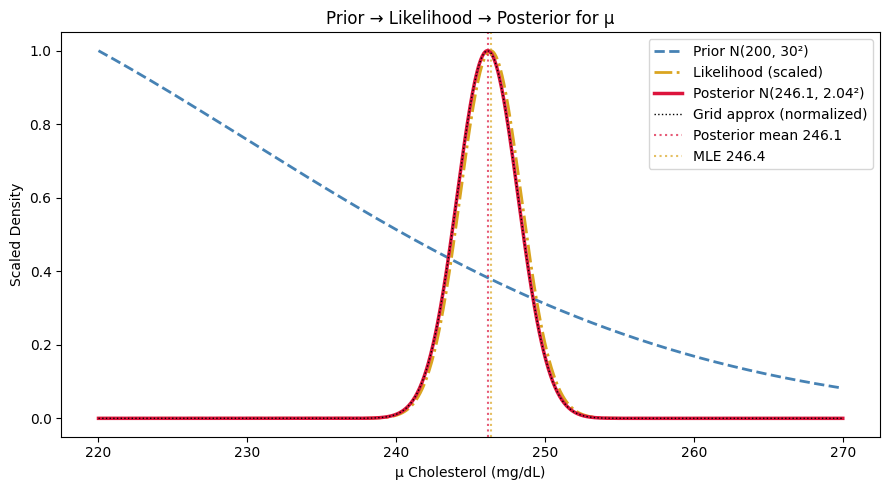

In [15]:
# --- Analytical posterior ---
prior_precision = 1 / tau_0**2
data_precision  = n / sigma**2
tau_n_sq = 1 / (prior_precision + data_precision)
tau_n    = np.sqrt(tau_n_sq)
mu_n     = tau_n_sq * (mu_0 / tau_0**2 + n * mu_mle / sigma**2)

print(f"Posterior mean (μ_n): {mu_n:.4f} mg/dL")
print(f"Posterior std  (τ_n): {tau_n:.4f} mg/dL")
print(f"Prior weight: {prior_precision/(prior_precision+data_precision)*100:.2f}%  |  Data weight: {data_precision/(prior_precision+data_precision)*100:.2f}%")

# --- Grid approximation (sanity check) ---
mu_grid        = np.linspace(220, 270, 2000)
log_post_grid  = norm.logpdf(mu_grid, mu_0, tau_0) + np.array([np.sum(norm.logpdf(chol_chd, mu, sigma)) for mu in mu_grid])
log_post_grid -= log_post_grid.max()
post_grid      = np.exp(log_post_grid)
post_grid     /= np.trapezoid(post_grid, mu_grid)  # use np.trapz if NumPy < 2.0

# --- Overlay plot ---
mu_range  = np.linspace(220, 270, 1000)
prior     = norm.pdf(mu_range, mu_0, tau_0)
log_lik   = np.array([np.sum(norm.logpdf(chol_chd, mu, sigma)) for mu in mu_range])
log_lik  -= log_lik.max()
lik_sc    = np.exp(log_lik) / np.exp(log_lik).max()
posterior = norm.pdf(mu_range, mu_n, tau_n)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(mu_range, prior/prior.max(),         color='steelblue', lw=2, linestyle='--', label=f'Prior N({int(mu_0)}, {int(tau_0)}²)')
ax.plot(mu_range, lik_sc,                    color='goldenrod', lw=2, linestyle='-.', label='Likelihood (scaled)')
ax.plot(mu_range, posterior/posterior.max(), color='crimson',   lw=2.5,              label=f'Posterior N({mu_n:.1f}, {tau_n:.2f}²)')
ax.plot(mu_grid,  post_grid/post_grid.max(), color='black',     lw=1, linestyle=':',  label='Grid approx (normalized)')
ax.axvline(mu_n,   color='crimson',   linestyle=':', alpha=0.7, label=f'Posterior mean {mu_n:.1f}')
ax.axvline(mu_mle, color='goldenrod', linestyle=':', alpha=0.7, label=f'MLE {mu_mle:.1f}')
ax.set_title('Prior → Likelihood → Posterior for μ'); ax.set_xlabel('μ Cholesterol (mg/dL)'); ax.set_ylabel('Scaled Density')
ax.legend(); plt.tight_layout(); plt.show()

### Credible Interval

In [16]:
ci_lo_bayes = norm.ppf(0.025, mu_n, tau_n)
ci_hi_bayes = norm.ppf(0.975, mu_n, tau_n)

print(f"95% Bayesian Credible Interval: ({ci_lo_bayes:.4f}, {ci_hi_bayes:.4f}) mg/dL")
print()
print("Interpretation: Given the data and our prior, there is a 95% probability")
print(f"that the true mean cholesterol μ lies between {ci_lo_bayes:.1f} and {ci_hi_bayes:.1f} mg/dL.")

95% Bayesian Credible Interval: (242.1342, 250.1367) mg/dL

Interpretation: Given the data and our prior, there is a 95% probability
that the true mean cholesterol μ lies between 242.1 and 250.1 mg/dL.


### 4. Posterior Predictive Analysis

The posterior predictive distribution gives the range of cholesterol values for a *new* CHD patient, marginalizing over uncertainty in μ:

$$p(\tilde{x} \mid \mathbf{x}) = \mathcal{N}(\mu_n,\, \sigma^2 + \tau_n^2)$$

This is wider than the credible interval because it adds individual-level variation (σ²) on top of parameter uncertainty (τ_n²).

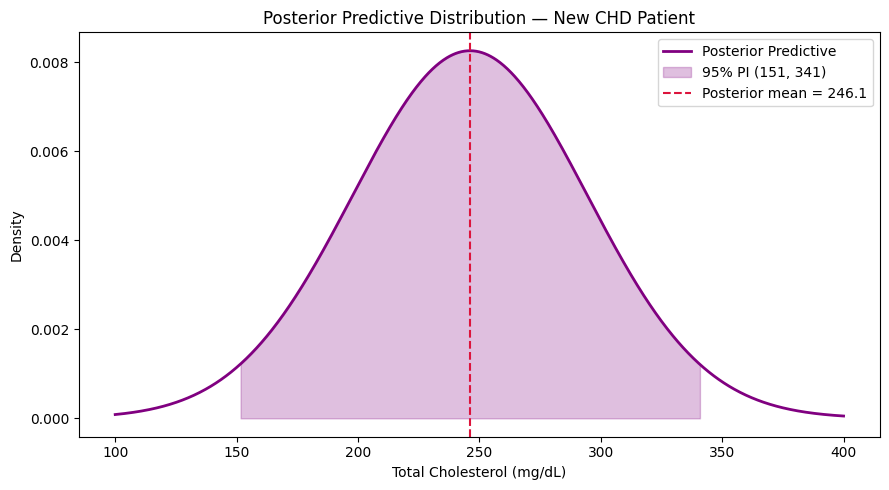

95% Predictive Interval: (151.40, 340.87) mg/dL
95% Credible Interval:   (242.13, 250.14) mg/dL
Predictive is 24x wider (individual σ = 48.3 dominates)


In [17]:
pred_std = np.sqrt(sigma**2 + tau_n**2)
pred_lo, pred_hi = norm.ppf(0.025, mu_n, pred_std), norm.ppf(0.975, mu_n, pred_std)

x_new = np.linspace(100, 400, 1000)
pred_density = norm.pdf(x_new, mu_n, pred_std)

plt.figure(figsize=(9, 5))
plt.plot(x_new, pred_density, color='purple', lw=2, label='Posterior Predictive')
plt.fill_between(x_new, pred_density, where=(x_new >= pred_lo) & (x_new <= pred_hi),
                 alpha=0.25, color='purple', label=f'95% PI ({pred_lo:.0f}, {pred_hi:.0f})')
plt.axvline(mu_n, color='crimson', linestyle='--', label=f'Posterior mean = {mu_n:.1f}')
plt.title('Posterior Predictive Distribution — New CHD Patient'); plt.xlabel('Total Cholesterol (mg/dL)'); plt.ylabel('Density')
plt.legend(); plt.tight_layout(); plt.show()

print(f"95% Predictive Interval: ({pred_lo:.2f}, {pred_hi:.2f}) mg/dL")
print(f"95% Credible Interval:   ({ci_lo_bayes:.2f}, {ci_hi_bayes:.2f}) mg/dL")
print(f"Predictive is {pred_std/tau_n:.0f}x wider (individual σ = {sigma:.1f} dominates)")

### Credible Interval vs. Confidence Interval Comparison

| Interval Type | Lower | Upper | Width | Interpretation |
|---|---|---|---|---|
| **Bayesian 95% Credible Interval** | 242.13 | 250.14 | 8.00 | 95% *probability* μ is in this range given the data |
| **Frequentist 95% CI (t-based)** | 242.33 | 250.37 | 8.04 | 95% of such intervals contain the true μ over repeated sampling |
| **Bootstrap 95% CI** | 242.49 | 250.43 | 7.94 | Empirical sampling distribution of the mean |
| **Posterior Predictive 95% PI** | 151.40 | 340.87 | 189.47 | Range for a *new individual* observation |

**Key distinctions:**

The credible interval and both frequentist intervals are nearly identical in width (~8 mg/dL), which is expected: with n = 557 observations, the data precision overwhelms the prior, and the Bayesian posterior converges to the frequentist solution. However, their interpretations differ fundamentally. The credible interval supports a direct probability statement — there is a 95% probability that μ ∈ (242.1, 250.1) given our data and prior. The frequentist CI makes no such claim; it instead says that 95% of intervals constructed this way over repeated samples would contain the true μ. The bootstrap CI corroborates both, confirming the sampling distribution of the mean is well-behaved at this sample size.

The posterior predictive interval (151.4, 340.9) is a different quantity entirely. At 189.5 mg/dL wide — roughly 24x the credible interval — it reflects where a *new individual* CHD patient's cholesterol is likely to fall, not where the mean is. This width is dominated by individual-level variation (σ ≈ 48 mg/dL) and cannot be reduced by collecting more data the way the credible interval can.